In [1]:
# !pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import yfinance as yf  # para baixar dados de ações

In [8]:
df = yf.download("AAPL", start='2018-01-01')
df

/var/folders/4g/hm9d3pn57nv1p17qlv8k47mc0000gn/T/ipykernel_25394/988960960.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start='2018-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.380997,40.390375,39.677740,39.888719,102223600
2018-01-03,40.373966,40.917820,40.310676,40.444293,118071600
2018-01-04,40.561493,40.664638,40.338796,40.446626,89738400
2018-01-05,41.023304,41.110038,40.566188,40.657611,94640000
2018-01-08,40.870922,41.166289,40.772463,40.870922,82271200
...,...,...,...,...,...
2025-10-10,245.270004,256.380005,244.000000,254.940002,61999100
2025-10-13,247.660004,249.690002,245.559998,249.380005,38142900


In [7]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

<Axes: xlabel='Date'>

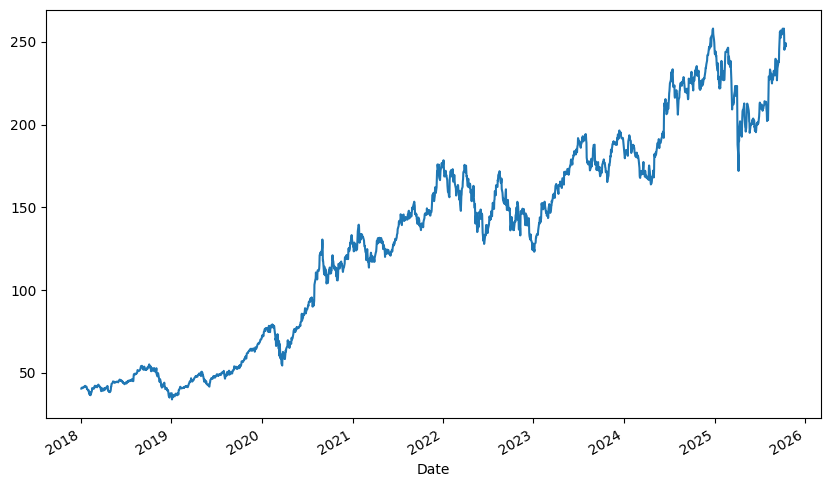

In [9]:
df[('Close', "AAPL")].plot(figsize=(10, 6))

In [3]:
def series_to_supervised(data, n_lags=5):
    """
    Converte array 1D em matriz (X, y) onde X contém lags e y é valor futuro (um passo).
    """
    X, y = [], []
    for i in range(n_lags, len(data)):
        X.append(data[i-n_lags:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [11]:
X, y = series_to_supervised(df[('Close', "AAPL")].values, n_lags=5)
X


array([[ 40.3809967 ,  40.37396622,  40.56149292,  41.02330399,
         40.87092209],
       [ 40.37396622,  40.56149292,  41.02330399,  40.87092209,
         40.86623764],
       [ 40.56149292,  41.02330399,  40.87092209,  40.86623764,
         40.85686493],
       ...,
       [256.48001099, 258.05999756, 254.03999329, 245.27000427,
        247.66000366],
       [258.05999756, 254.03999329, 245.27000427, 247.66000366,
        247.77000427],
       [254.03999329, 245.27000427, 247.66000366, 247.77000427,
        249.33999634]])

In [12]:
def train_and_eval_ml(symbol="AAPL", start="2018-01-01", end="2023-01-01", n_lags=5):
    # baixar série de fechamento ajustado
    df = yf.download(symbol, start=start, end=end)
    series = df[('Close', symbol)].dropna().values

    # converter para dados supervisionados
    X, y = series_to_supervised(series, n_lags=n_lags)

    # dividir treino/teste (por exemplo 80/20)
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # escalar (importante para SVR)
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    X_train_s = scaler_x.fit_transform(X_train)
    X_test_s = scaler_x.transform(X_test)
    y_train_s = scaler_y.fit_transform(y_train.reshape(-1,1)).ravel()
    # notamos que o y_test será comparado no espaço original, então convert de volta depois

    # Regressão Linear
    model_lr = LinearRegression()
    model_lr.fit(X_train_s, y_train_s)

    # SVR
    model_svr = SVR(kernel='rbf', C=100, gamma='auto')
    model_svr.fit(X_train_s, y_train_s)

    # fazer predições (em escala) e inverter escala
    y_pred_lr_s = model_lr.predict(X_test_s)
    y_pred_svr_s = model_svr.predict(X_test_s)
    y_pred_lr = scaler_y.inverse_transform(y_pred_lr_s.reshape(-1,1)).ravel()
    y_pred_svr = scaler_y.inverse_transform(y_pred_svr_s.reshape(-1,1)).ravel()

    # avaliar
    def eval_metrics(y_true, y_pred, model_name="Model"):
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        print(f"{model_name}: RMSE = {rmse:.4f}, MAE = {mae:.4f}")

    eval_metrics(y_test, y_pred_lr, "Linear Regression")
    eval_metrics(y_test, y_pred_svr, "SVR")

    # gráficos
    plt.figure(figsize=(12,5))
    plt.plot(range(len(y_test)), y_test, label="Real")
    plt.plot(range(len(y_test)), y_pred_lr, label="LR Predito")
    plt.plot(range(len(y_test)), y_pred_svr, label="SVR Predito")
    plt.legend()
    plt.title(f"Comparação: real vs preditos ({symbol})")
    plt.show()

    # gráfico de erros (resíduos)
    plt.figure(figsize=(12,4))
    plt.plot(y_test - y_pred_lr, label="Erro LR")
    plt.plot(y_test - y_pred_svr, label="Erro SVR")
    plt.legend()
    plt.title("Resíduos (y_true – y_pred)")
    plt.show()

    return {
        'y_test': y_test,
        'y_pred_lr': y_pred_lr,
        'y_pred_svr': y_pred_svr,
        'model_lr': model_lr,
        'model_svr': model_svr,
        'scaler_x': scaler_x,
        'scaler_y': scaler_y
    }


/var/folders/4g/hm9d3pn57nv1p17qlv8k47mc0000gn/T/ipykernel_25394/3747040539.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


Linear Regression: RMSE = 5.2289, MAE = 3.9871
SVR: RMSE = 62.1058, MAE = 42.9173


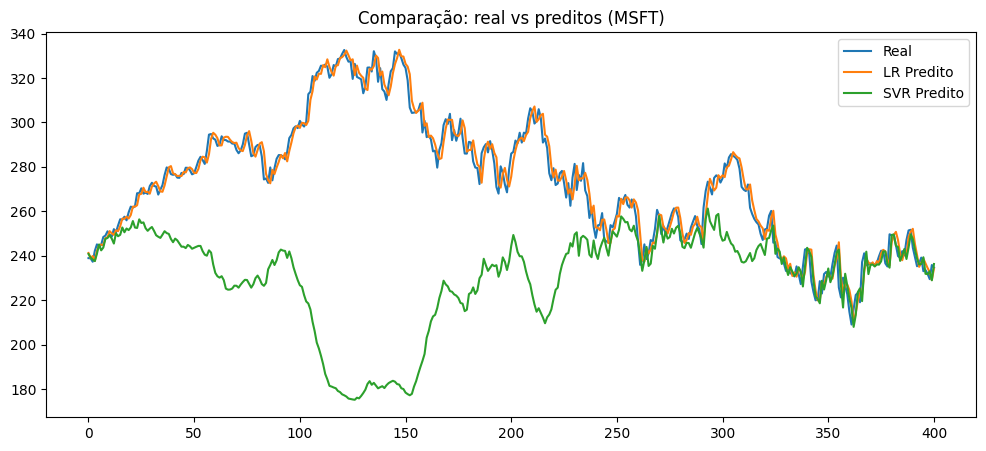

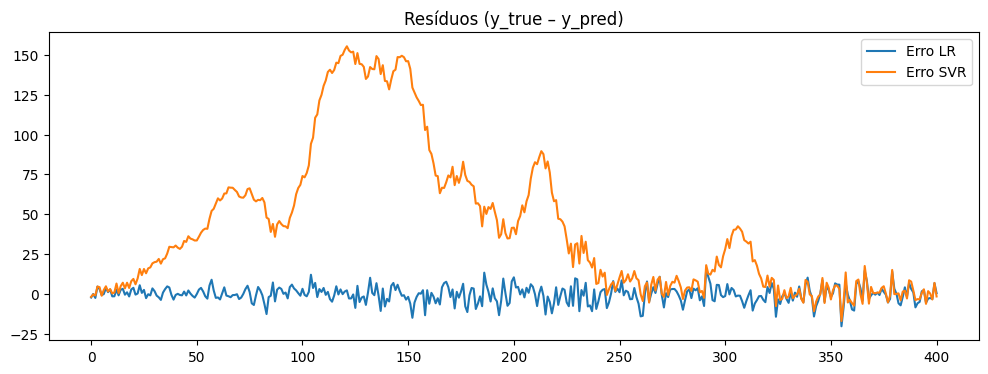

In [13]:
res = train_and_eval_ml("MSFT", start="2015-01-01", end="2023-01-01", n_lags=10)